In [2]:
# ============================================================
# 1. Install Dependencies
# ============================================================
!pip install -q transformers datasets peft accelerate bitsandbytes trl sentencepiece
!pip install -q huggingface_hub evaluate rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 885.0/885.0 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [3]:
# ============================================================
# 2. Imports and Hugging Face Login
# ============================================================
import torch
import json
from datasets import load_dataset, Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from huggingface_hub import login

# Login to Hugging Face (required for Gemma)
login()

In [4]:
# ============================================================
# 3. Load Dataset
# ============================================================
print("Loading dataset...")
dataset = load_dataset("naver-clova-ix/cord-v2", split="train")
print(f"Loaded {len(dataset)} samples")

Loading dataset...


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…): reconstructing file:   0%|          |  0.00B /  490MB            

data/train-00000-of-00004-b4aaeceff1d90e(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-9c204eb3f4e1179(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Loaded 800 samples


In [5]:
# ============================================================
# 4. Dataset Processing
# ============================================================
FIELD_MAP = {
    "total": "Total",
    "sub_total": "Subtotal"
}

def process_sample(sample):
    gt_data = json.loads(sample['ground_truth'])
    gt_parse = gt_data['gt_parse']

    doc_parts = []
    if 'menu' in gt_parse:
        menu_items = gt_parse['menu']
        if not isinstance(menu_items, list):
            menu_items = []
        for item in menu_items:
            if isinstance(item, dict):
                nm = item.get('nm', '')
                cnt = item.get('cnt', '')
                price = item.get('price', '')
                if nm:
                    doc_parts.append(f"{nm} {cnt} {price}".strip())
            elif isinstance(item, str):
                doc_parts.append(item)

    if 'sub_total' in gt_parse:
        doc_parts.append(f"Subtotal: {gt_parse['sub_total']}")
    if 'total' in gt_parse:
        doc_parts.append(f"Total: {gt_parse['total']}")

    doc_text = " ".join(doc_parts)

    target = {}
    for cat, new_name in FIELD_MAP.items():
        if cat in gt_parse:
            target[new_name] = gt_parse[cat]
    return doc_text, target

def format_example(doc, target):
    prompt = f"Extract the following information from the document: Total, Subtotal.\n\nDocument:\n{doc}\n\nAnswer:\n"
    answer = json.dumps(target, ensure_ascii=False)
    return prompt + answer

print("Processing samples...")
prepared_data = []
for idx, sample in enumerate(dataset):
    doc, target = process_sample(sample)
    if 'Total' not in target or len(doc) < 10:
        continue
    text = format_example(doc, target)
    prepared_data.append({"text": text})

full_dataset = Dataset.from_list(prepared_data)
split_dataset = full_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(f"Train size: {len(train_dataset)}")
print(f"Eval size: {len(eval_dataset)}")

Processing samples...
Train size: 718
Eval size: 80


In [6]:
# ============================================================
# 5. Load Tokenizer and Model
# ============================================================
model_name = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.00GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

In [7]:
# ============================================================
# 6. Apply LoRA
# ============================================================
model = prepare_model_for_kbit_training(model)
model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,490,944 || all params: 1,001,376,896 || trainable%: 0.1489


In [8]:
# ============================================================
# 7. Tokenize Dataset
# ============================================================
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512, padding=False)

tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_eval = eval_dataset.map(tokenize_function, batched=True, remove_columns=["text"])

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

Map:   0%|          | 0/718 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

In [9]:
# ============================================================
# 8. Training Setup
# ============================================================
training_args = TrainingArguments(
    output_dir="./gemma3-cord-lora",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    save_total_limit=2,
    learning_rate=2e-4,
    fp16=True,
    max_grad_norm=0.3,
    warmup_steps=30,
    lr_scheduler_type="cosine",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    data_collator=data_collator,
)

In [10]:
# ============================================================
# 9. Train the Model
# ============================================================
print("Starting training...")
trainer.train()
print("Training complete!")

Starting training...


Step,Training Loss,Validation Loss
100,0.787698,0.686195
200,0.668710,0.595280
270,0.681864,0.582029


Training complete!


In [11]:
# ============================================================
# 10. Save the Adapter
# ============================================================
model.save_pretrained("_gemma3-cord-lora-final")
tokenizer.save_pretrained("_gemma3-cord-lora-final")
print("Adapter and tokenizer saved successfully!")

Adapter and tokenizer saved successfully!


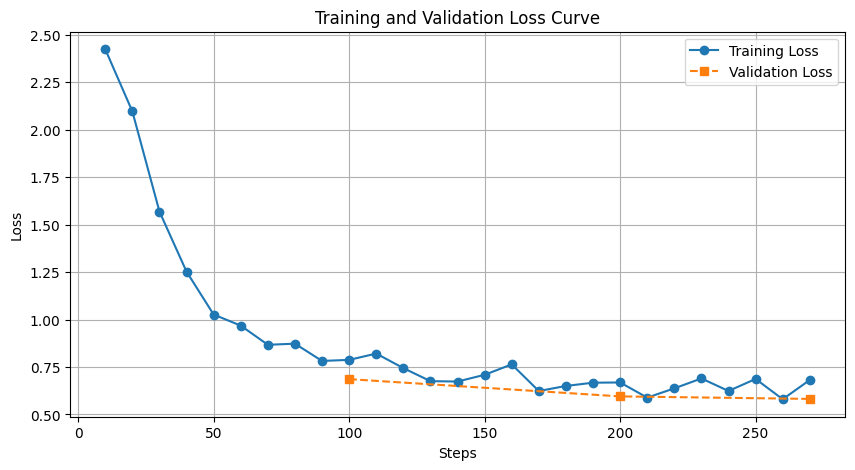

In [12]:
# ============================================================
# 11. Plotting the Training Loss Curve
# ============================================================
import matplotlib.pyplot as plt

# Extract loss values from the trainer's history
logs = trainer.state.log_history

# Separate training loss and validation loss
train_loss = []
eval_loss = []
steps = []
eval_steps = []

for log in logs:
    if 'loss' in log:
        train_loss.append(log['loss'])
        steps.append(log['step'])
    if 'eval_loss' in log:
        eval_loss.append(log['eval_loss'])
        eval_steps.append(log['step'])

# Plot
plt.figure(figsize=(10, 5))
if train_loss:
    plt.plot(steps, train_loss, label='Training Loss', marker='o', linestyle='-')
if eval_loss:
    plt.plot(eval_steps, eval_loss, label='Validation Loss', marker='s', linestyle='--')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig('training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# 10. Downloading the Image
# ============================================================
from google.colab import files
files.download('training_loss.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>